In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, roc_curve, auc, f1_score, accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import root_mean_squared_error

В цьому домашньому завданні ми проведемо додаткові експерименти для рішення задачі бінарної класифікації і створимо ваш новий submission на змагання на Kaggle.

-----------


**Завдання 0**. Завантажте дані `train.csv`, `test.csv`, `sample_submission.csv` зі змагання на Kaggle - шукайте посилання в уроці [Запрошення до участі у Kaggle-змаганні.](https://data-loves.kwiga.com/courses/machine-learning-dlia-liudei/domashnie-zavdannia-zmagannia-z-kaggle)  Для завантаження потрібно долучитись до змагання (натиснути кнопку "Join").


**Завдання 1**. **Збираємо весь код з попереднього ДЗ в одному місці.** В лекційному ноутбуці `Логістична регресія з ScikitLearn. Повна ML задача.ipynb` ми познайомились з поняттям пайплайнів, а також я показала, як компактно виглядає рішення МЛ задачі, якщо ми зберемо весь код разом.

Оскільки ми далі будемо робити експерименти, які включають ті самі етапи попередньої обробки, але інше моделювання - буде зручно мати весь код компактно і під рукою. Тому зараз ми займемось збором коду до купи :) Після цього завдання для подальших експериментів ви можете перенести частини розвʼязку взагалі в окремий `.py` файл, аби було зручно імпортувати функції.

Зі свого рішення в попередньому домашньому завданні (`Логістична регресія з scikit learn.ipynb`) зберіть усі кроки розвʼязку задачі разом з використанням `sklearn.Pipeline` за прикладом з лекції.

Ваш код нижче має містити
1. Читання даних з файлу (поза пайплайном).
2. Розбиття на тренувальний і валідаційний набори, де валідаційний містить 20% даних (поза пайплайном).
3. Виділення категоріальних і числових колонок (поза пайплайном).
4. Підготовку категоріальних і числових колонок (частина пайплайну). В прикладі в лекції ми оформлювали обробку числових і категоріальних колонок в окремі трансформери `numeric_transformer`, `categorical_cols`. Рекоемндую зробити саме так, так потім зручніше вносити зміни :)
5. Тренування лог регресії (частина пайплайну).
6. Запуск пайплайну на тренування на трен. даних (поза пайплайном).
7. Запуск пайплайну на передбачення на трен і вал. даних і вимір метрик якості ROC-AUC + вивдення Confusion Matrix (поза пайплайном).
8. Збереження моделі в формат joblib (поза пайплайном).

Ви це все вже зробили в попереднтьому ДЗ! Тож, тут просто заадча все зібрати разом.

Нижче я додала підказки, що покроково ви маєте зробити. Якщо ви почуваєтесь впевнено, можете видалити ці підказки і реалізувати все самостійно, або ж - просто заповнити пропуски.

Завдання оцінюється в 10 балів. Головний результат - аби код в фіналі був робочий. Бо за не робочий нам гроші ніхто не заплатить :)

In [8]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
sample_submission = pd.read_csv('sample_submission.csv')

Area under ROC score on Train dataset: 0.88%


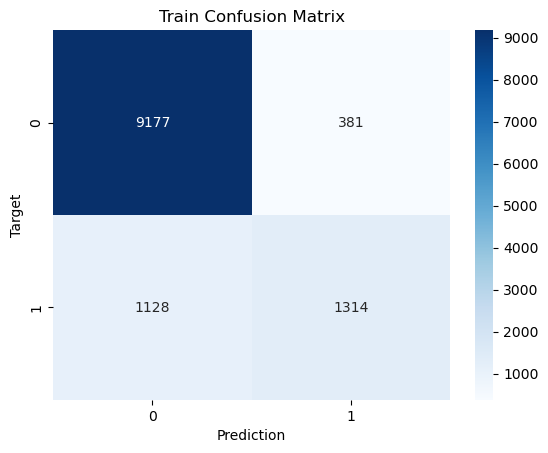

Area under ROC score on Validation dataset: 0.88%


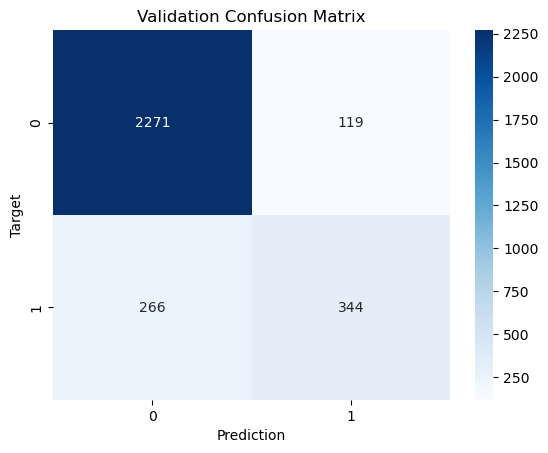

['customer_churn.joblib']

In [9]:
raw_df = pd.read_csv('test.csv', index_col=0)

train_df, val_df = train_test_split(train, test_size=0.2, random_state=42, stratify=train['Exited'])

# Створюємо трен. і вал. набори
input_cols = list(train_df.columns)[1:-1]
target_col = 'Exited'
train_inputs, train_targets = train_df[input_cols].copy(), train_df[target_col].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df[target_col].copy()

# Виявляємо числові і категоріальні колонки
numeric_cols = list(train_inputs.select_dtypes('number').columns)
numeric_cols.remove('CustomerId')

categorical_cols = list(train_inputs.select_dtypes('object').columns)
categorical_cols.remove('Surname')

# Створюємо трансформери для числових і категоріальних колонок
numeric_transformer = Pipeline(steps=[
    ('scaler', MinMaxScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

# Комбінуємо трансформери для різних типів колонок в один препроцесор
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

# Стоврюємо пайплайн, який спочатку запускає препроцесинг, потім тренуєм модель
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='liblinear'))
])

# Тренуємо пайплайн
model_pipeline.fit(train_inputs, train_targets)

# Функція, щоб передбачати і рахувати метрики
def predict_and_plot(model_pipeline, inputs, targets, name=''):
    preds = model_pipeline.predict(inputs)
    y_pred_proba = model_pipeline.predict_proba(inputs)[:, 1]
    fpr, tpr, thresholds = roc_curve(targets, y_pred_proba)
    roc_auc = auc(fpr, tpr)
    print(f"Area under ROC score on {name} dataset: {roc_auc:.2f}%")
    confusion_matrix_ = confusion_matrix(targets, preds)
    plt.figure()
    sns.heatmap(confusion_matrix_, annot=True, cmap='Blues', fmt='d')
    plt.xlabel('Prediction')
    plt.ylabel('Target')
    plt.title('{} Confusion Matrix'.format(name))
    plt.show()
    return preds

# Оцінюємо модель на трен і вал даних
train_preds = predict_and_plot(model_pipeline, train_inputs, train_targets, 'Train')
val_preds = predict_and_plot(model_pipeline, val_inputs, val_targets, 'Validation')

# Зберігаємо модель для подальшого використання
joblib.dump(model_pipeline, 'customer_churn.joblib')


**Завдання 2**. Такс, у нас з вами є вже готовий пайплайн. Давайте проведемо нові експерименти.

  Додайте в попередню обробку числових колонок генерацію polinomal features до степені 2 включно. Для цього створіть новий препроцесор і створіть новий пайплайн.

  Запустіть пайплайн на тренування і виведіть метрики для тренувального і валідаційного набору. Напишіть, як вам модель? Чи спостерігається в цій моделі overfit чи underfit? Чи ця модель добре генералізує?

Area under ROC score on Train dataset: 0.92%


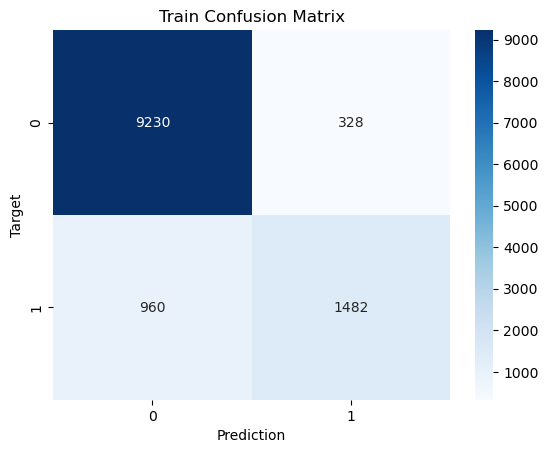

Area under ROC score on Validation dataset: 0.92%


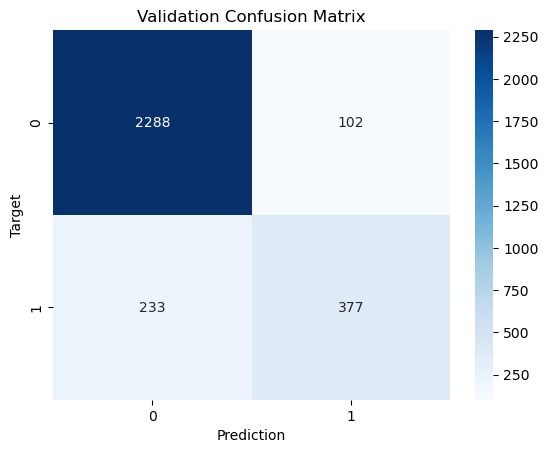

In [10]:
numeric_transformer_poly = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=2))
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor_poly = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly, numeric_cols),
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly = Pipeline(steps=[
    ('preprocessor', preprocessor_poly),
    ('classifier', LogisticRegression(solver='liblinear'))
])

model_pipeline_poly.fit(train_inputs, train_targets)

train_preds_poly = predict_and_plot(model_pipeline_poly, train_inputs, train_targets, 'Train')
val_preds_poly = predict_and_plot(model_pipeline_poly, val_inputs, val_targets, 'Validation')

Модель показала себе чудово, ROC-AUC відчутно зросла з 0.88 до 0.92
Overfit чи underfit немає, модель показує хороший результат на тренувальних і валідаційних даних

**Завдання 3**. Тепер давайте створимо ще новий пайплайн, тільки тепер поліноміальні ознаки згенеруємо до степені 4. Зробіть висновок про якість моделі. Якщо вам подобається резульат якоїсь з моделей в цьому ДЗ - рекомендую зробити submission в змаганні.

Area under ROC score on Train dataset: 0.93%


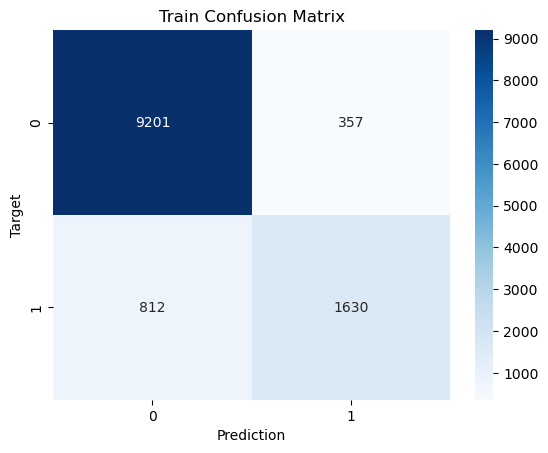

Area under ROC score on Validation dataset: 0.93%


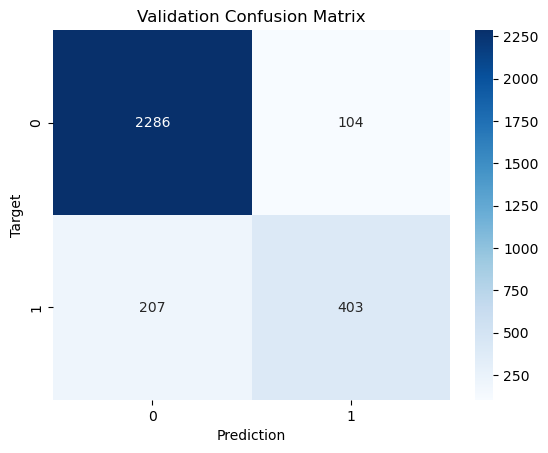

In [11]:
numeric_transformer_poly4 = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('poly', PolynomialFeatures(degree=4)) 
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
])

preprocessor_poly4 = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer_poly4, numeric_cols), 
        ('cat', categorical_transformer, categorical_cols)
    ])

model_pipeline_poly4 = Pipeline(steps=[
    ('preprocessor', preprocessor_poly4),
    ('classifier', LogisticRegression(solver='liblinear', max_iter=2000))
])

model_pipeline_poly4.fit(train_inputs, train_targets)


train_preds_poly4 = predict_and_plot(model_pipeline_poly4, train_inputs, train_targets, 'Train')
val_preds_poly4 = predict_and_plot(model_pipeline_poly4, val_inputs, val_targets, 'Validation')

Якість моделі трохи вища порівняно з degree=2, ROC-AUC зросла до 0.93

**Завдання 4. Перенавчання і регуляризація**.

  Скачайте набір даних `regression_data.csv`. Звичайте набір даних з `regression_data.csv`, розбийте на train і test (в тест 20%) і натренуйте модель лінійної регресії з масштабуванням числових ознак і поліноміальними ознаками до степені **5 включно**.

  Виміряйте якість прогностичної моделі і зробіть висновок, чи модель хороша, чи вона добре генералізує?


In [39]:
df = pd.read_csv('regression_data.csv', index_col=0)
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42)

input_cols = list(train_df.columns)[:-1]
train_inputs, train_targets = train_df[input_cols].copy(), train_df['target'].copy()
val_inputs, val_targets = val_df[input_cols].copy(), val_df['target'].copy()

In [40]:
scaler = MinMaxScaler().set_output(transform="pandas")
scaler.fit(train_inputs)
train_inputs = scaler.transform(train_inputs)
val_inputs = scaler.transform(val_inputs)

In [43]:
for i in range(1, 6):
    poly_features = PolynomialFeatures(degree=i)
    X_train_poly = poly_features.fit_transform(train_inputs)
    X_val_poly = poly_features.transform(val_inputs)
    
    poly_reg = LinearRegression()
    poly_reg.fit(X_train_poly, train_targets)
    y_pred_train_poly = poly_reg.predict(X_train_poly)
    y_pred_val_poly = poly_reg.predict(X_val_poly)
    
    
    rmse_poly_train = root_mean_squared_error(train_targets, y_pred_train_poly)
    rmse_poly_val = root_mean_squared_error(val_targets, y_pred_val_poly)
    print(f'degree = {i}, rmse train = {round(rmse_poly_train, 2)},  rmse val = {round(rmse_poly_val, 2)}')

degree = 1, rmse train = 1.08,  rmse val = 0.85
degree = 2, rmse train = 1.04,  rmse val = 0.91
degree = 3, rmse train = 0.89,  rmse val = 1.77
degree = 4, rmse train = 0.65,  rmse val = 8.77
degree = 5, rmse train = 0.0,  rmse val = 90.2


З зростанням степеня помилка на тренувальних даних падає, а на валідаціних росте, на 5 степені відбувається значне збільшення помилки на валідаційних даних, а на тренувальних помилка стає 0

**Завдання 5**. Натренуйте моделі Lasso(), Ridge(), ElasaticNet() на цих даних (з поліном ознаками до степені 20 включно), порівняйте якість з тою, яка була отримана з лінійною регресією. Яка модель найкраще генералізує і чому на ваш погляд (можливо треба буде для відповіді зробити додатковий аналіз ознак)?

In [56]:
for model in [Lasso(), Ridge(), ElasticNet()]:
    for i in range(1, 21):
        poly_features = PolynomialFeatures(degree=i)
        X_train_poly = poly_features.fit_transform(train_inputs)
        X_val_poly = poly_features.transform(val_inputs)
        
        model.fit(X_train_poly, train_targets)
        y_pred_train_poly = model.predict(X_train_poly)
        y_pred_val_poly = model.predict(X_val_poly)
        
        
        rmse_poly_train = root_mean_squared_error(train_targets, y_pred_train_poly)
        rmse_poly_val = root_mean_squared_error(val_targets, y_pred_val_poly)
        print(f'model = {model}, degree = {i}, rmse train = {round(rmse_poly_train, 2)},  rmse val = {round(rmse_poly_val, 2)}')
    print('\n')

model = Lasso(), degree = 1, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 2, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 3, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 4, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 5, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 6, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 7, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 8, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 9, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 10, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 11, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 12, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 13, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 14, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 15, rmse train = 5.1,  rmse val = 5.67
model = Lasso(), degree = 16, rmse

Cтандартний параметр alpha=1 є занадто великим для цих даних і призводять до недонавчання. Тому було проведено налаштування рпараметра alpha до значення 0.01. Це кардинально змінило результати:

In [68]:
for model in [Lasso(0.01), Ridge(0.01), ElasticNet(0.01)]:
    for i in range(1, 21):
        poly_features = PolynomialFeatures(degree=i)
        X_train_poly = poly_features.fit_transform(train_inputs)
        X_val_poly = poly_features.transform(val_inputs)
        
        model.fit(X_train_poly, train_targets)
        y_pred_train_poly = model.predict(X_train_poly)
        y_pred_val_poly = model.predict(X_val_poly)
        
        
        rmse_poly_train = root_mean_squared_error(train_targets, y_pred_train_poly)
        rmse_poly_val = root_mean_squared_error(val_targets, y_pred_val_poly)
        print(f'model = {model}, degree = {i}, rmse train = {round(rmse_poly_train, 2)},  rmse val = {round(rmse_poly_val, 2)}')
    print('\n')

model = Lasso(alpha=0.01), degree = 1, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 2, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 3, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 4, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 5, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 6, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 7, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 8, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 9, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 10, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 11, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 12, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0.01), degree = 13, rmse train = 1.08,  rmse val = 0.84
model = Lasso(alpha=0

C:\Users\leshchuk\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 2.026e+01, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


model = ElasticNet(alpha=0.01), degree = 19, rmse train = 5.08,  rmse val = 6.04
model = ElasticNet(alpha=0.01), degree = 20, rmse train = 5.08,  rmse val = 6.03




C:\Users\leshchuk\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 3.285e+01, tolerance: 2.006e+01
  model = cd_fast.enet_coordinate_descent(


Модель Ridge на 2-му та 3-му степенях полінома показала найкращий результат серед усіх, RMSE на валідації склав 0.75. Модель Lasso не змінюється залежно від степеня, ElasticNet є найгіршою моделлю для цих даних.